In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import skimage as ski
import numpy as np
import matplotlib.pyplot as plt
import random
import rasterio
from pathlib import Path

Selection of the data files

In [ ]:
dataset_path = Path("/content/drive/MyDrive/ProjetBIP")
tiles_path = dataset_path / "tiles"
masks_path = dataset_path / "masks"

In [ ]:
tile_files = list(tiles_path.glob("tile_*.tif"))
#print (len(tile_files))
#We have 330 images

Selection of 6 random files

In [ ]:
selected_files = random.sample(tile_files, 2)

for tile_path in selected_files:
  #print(tile_path)
  img = ski.io.imread(tile_path)
  #print (img.shape , img.dtype)
  idx = tile_path.stem.split("_")[1]
  mask_path = masks_path / f"mask_{idx}.tif"

  mask = ski.io.imread(mask_path)
  #print (mask.shape , mask.dtype)

Visualization of 6 random images

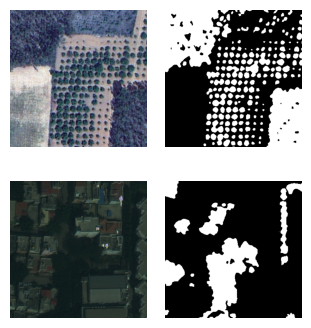

In [ ]:

n = len(selected_files)
fig, ax = plt.subplots(n, 2, figsize=[4, n * 2])

for i, tile_path in enumerate(selected_files):
    idx = tile_path.stem.split("_")[1]
    mask_path = masks_path / f"mask_{idx}.tif"

    mask = ski.io.imread(mask_path)

    img = ski.io.imread(tile_path)
    blue = (img[0] - img[0].min()) / (img[0].max() - img[0].min())
    green = (img[1] - img[1].min()) / (img[1].max() - img[1].min())
    yellow = (img[2] - img[2].min()) / (img[2].max() - img[2].min())
    red = (img[3] - img[3].min()) / (img[3].max() - img[3].min())
    red_edge = (img[4] - img[4].min()) / (img[4].max() - img[4].min())
    nearIR1 = (img[5] - img[5].min()) / (img[5].max() - img[5].min())
    nearIR2 = (img[6] - img[6].min()) / (img[6].max() - img[6].min())
    combined = np.stack ( [ red , green, blue ] , axis = 2)
    ax[i, 0].imshow(combined)
    ax[i, 1].imshow(mask, cmap='gray')
    ax[i, 0].axis('off')
    ax[i, 1].axis('off')

plt.subplots_adjust(hspace=0.25, wspace=0.0)
plt.show()


Compared with the mask (under)

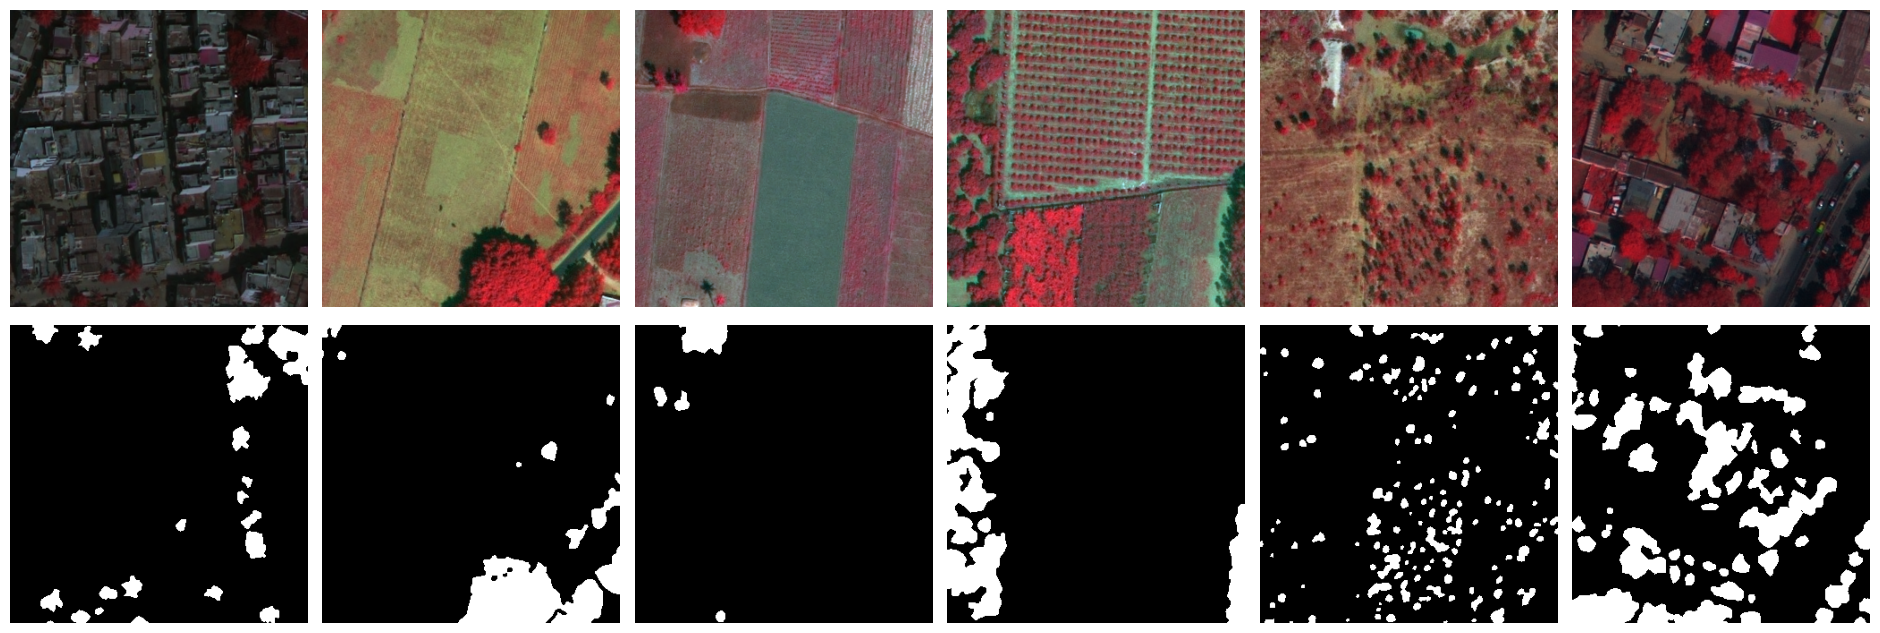

In [ ]:
fig,ax = plt.subplots(2,6, figsize = [24,8])

for i, tile_path in enumerate(selected_files):

    idx = tile_path.stem.split("_")[1]
    mask_path = masks_path / f"mask_{idx}.tif"

    mask = ski.io.imread(mask_path)

    img = ski.io.imread(tile_path)
    # The right channels i think
    blue = (img[0] - img[0].min()) / (img[0].max() - img[0].min())
    green = (img[1] - img[1].min()) / (img[1].max() - img[1].min())
    yellow = (img[2] - img[2].min()) / (img[2].max() - img[2].min())
    red = (img[3] - img[3].min()) / (img[3].max() - img[3].min())
    red_edge = (img[4] - img[4].min()) / (img[4].max() - img[4].min())
    nearIR1 = (img[5] - img[5].min()) / (img[5].max() - img[5].min())
    nearIR2 = (img[6] - img[6].min()) / (img[6].max() - img[6].min())
    combined = np.stack ( [ nearIR2 , red , green ] , axis = 2)
    ax[0,i].imshow(combined)
    ax[1,i].imshow(mask, cmap = 'gray')
    ax[0,i].axis('off')
    ax[1,i].axis('off')
plt.subplots_adjust(hspace=0.05, wspace=0.05)
plt.show()

With the mask stacked on it

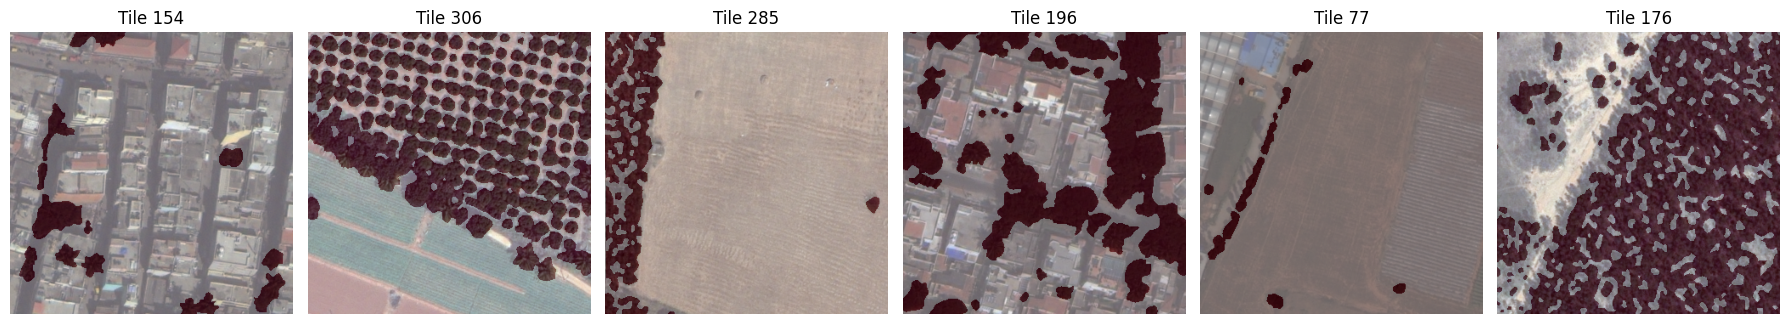

In [ ]:
fig, ax = plt.subplots(1, 6, figsize=(18, 5))

for i, tile_path in enumerate(selected_files):

    idx = tile_path.stem.split("_")[1]
    mask_path = masks_path / f"mask_{idx}.tif"

    img = ski.io.imread(tile_path)
    mask = ski.io.imread(mask_path)

    # The right channels i think
    blue = (img[0] - img[0].min()) / (img[0].max() - img[0].min())
    green = (img[1] - img[1].min()) / (img[1].max() - img[1].min())
    yellow = (img[2] - img[2].min()) / (img[2].max() - img[2].min())
    red = (img[3] - img[3].min()) / (img[3].max() - img[3].min())
    red_edge = (img[4] - img[4].min()) / (img[4].max() - img[4].min())
    nearIR1 = (img[5] - img[5].min()) / (img[5].max() - img[5].min())
    nearIR2 = (img[6] - img[6].min()) / (img[6].max() - img[6].min())
    combined = np.stack ( [ red , green , blue] , axis = 2)

    # Affichage
    ax[i].imshow(combined)
    ax[i].imshow(mask, cmap='Reds', alpha=0.4)

    ax[i].set_title(f"Tile {idx}")
    ax[i].axis('off')

plt.tight_layout()
plt.show()

Vizualization of all 7 channels on an image


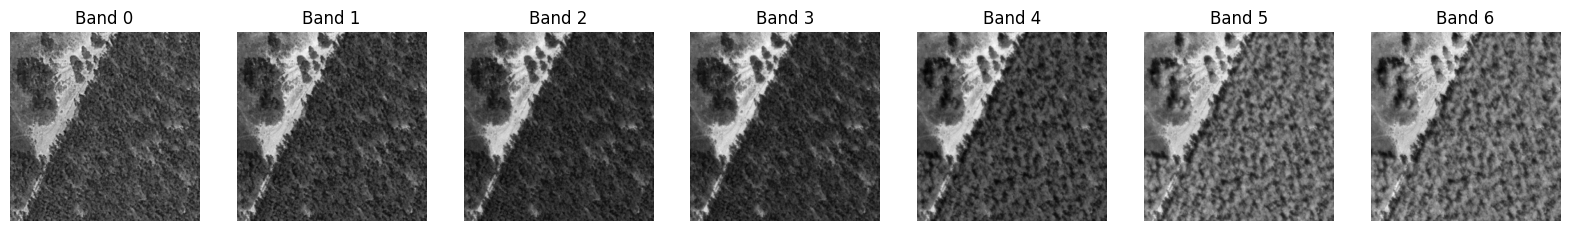

In [ ]:
fig, ax = plt.subplots(1, 7, figsize=(20, 4))

for b in range(7):
    ax[b].imshow(img[b, :, : ], cmap='gray')
    ax[b].set_title(f"Band {b}")
    ax[b].axis('off')

Vizualization of the NDVI for theses images

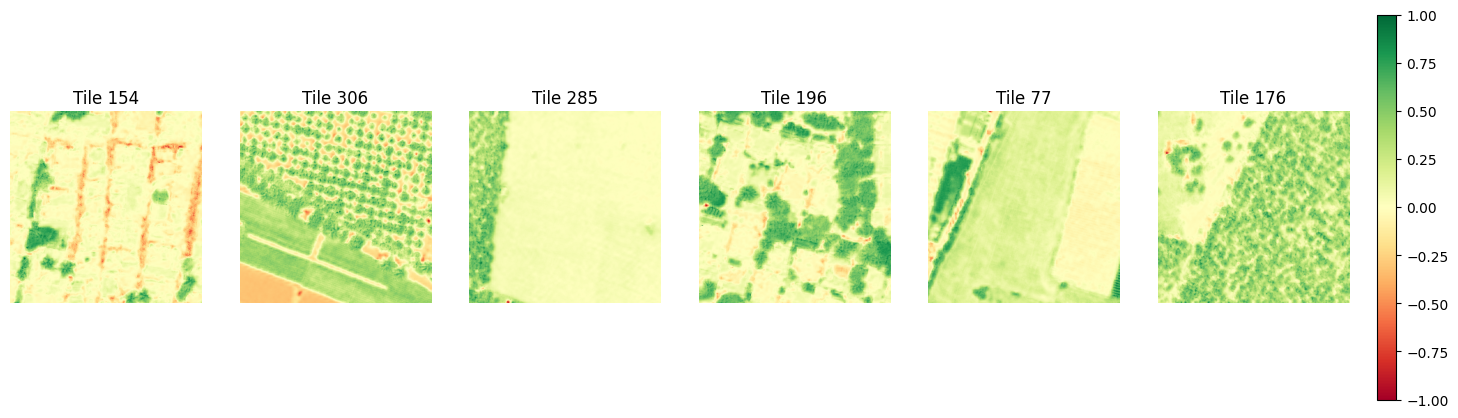

In [ ]:
fig, ax = plt.subplots(1, 6, figsize=(18, 5))

for i, tile_path in enumerate(selected_files):

    idx = tile_path.stem.split("_")[1]
    mask_path = masks_path / f"mask_{idx}.tif"

    img = ski.io.imread(tile_path)
    mask = ski.io.imread(mask_path)

    # The right channels i think
    blue = (img[0] - img[0].min()) / (img[0].max() - img[0].min())
    green = (img[1] - img[1].min()) / (img[1].max() - img[1].min())
    yellow = (img[2] - img[2].min()) / (img[2].max() - img[2].min())
    red = (img[3] - img[3].min()) / (img[3].max() - img[3].min())
    red_edge = (img[4] - img[4].min()) / (img[4].max() - img[4].min())
    nearIR1 = (img[5] - img[5].min()) / (img[5].max() - img[5].min())
    nearIR2 = (img[6] - img[6].min()) / (img[6].max() - img[6].min())

    ndvi = (nearIR1 - red) / (nearIR1 + red)

     # Affichage
    im = ax[i].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax[i].set_title(f"Tile {idx}")
    ax[i].axis('off')

# Colorbar globale
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)

plt.show()


Histogram of the tree coverage

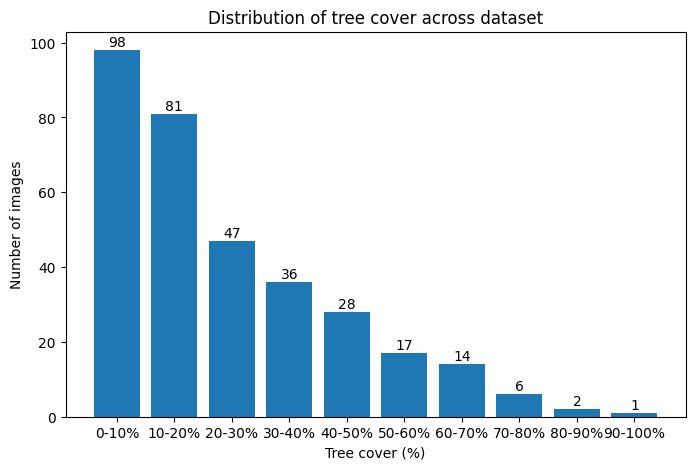

In [ ]:
ratios = []

for tile_path in tile_files:

    idx = tile_path.stem.split("_")[1]
    mask_path = masks_path / f"mask_{idx}.tif"

    mask = ski.io.imread(mask_path)

    # Binarisation si nécessaire
    mask = (mask > 0).astype(np.uint8)

    tree_pixels = np.sum(mask)
    total_pixels = mask.size

    ratio = tree_pixels / total_pixels

    ratios.append(ratio)

bins = np.linspace(0, 1, 11)
hist, edges = np.histogram(ratios, bins=bins)

labels = [f"{int(edges[i]*100)}-{int(edges[i+1]*100)}%" for i in range(len(edges)-1)]

plt.figure(figsize=(8,5))
plt.bar(labels, hist)

plt.xlabel("Tree cover (%)")
plt.ylabel("Number of images")
plt.title("Distribution of tree cover across dataset")
for i, v in enumerate(hist):
    plt.text(i, v + 1, str(v), ha='center')

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

tile_files = sorted(list(tiles_path.glob("tile_*.tif")))

train_files, test_files = train_test_split(tile_files, test_size=0.15, random_state=42)
train_files, val_files = train_test_split(train_files, test_size=0.1765, random_state=42)

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

Train: 230
Val: 50
Test: 50
